In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/nunnarilabs/ml/master/house/kc_house_data.csv"
df = pd.read_csv(url)

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df = df[['price', 'sqft_living', 'bedrooms', 'bathrooms']]
df.dropna(inplace=True)

In [4]:
X = df[['sqft_living', 'bedrooms', 'bathrooms']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SIMPLE LINEAR REGRESSION


In [5]:
X_simple = df[['sqft_living']]
y = df['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

In [6]:
print("Simple Linear Regression:")
print("MSE:", mean_squared_error(y_test_s, y_pred_s))
print("MAE:", mean_absolute_error(y_test_s, y_pred_s))
print("R2 Score:", r2_score(y_test_s, y_pred_s))

Simple Linear Regression:
MSE: 76484977061.77612
MAE: 177867.54034434858
R2 Score: 0.49406905389089006


MULTIVARIANT(MULTIPLE)REGRESSION


In [7]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_m = model_multi.predict(X_test)

In [8]:
print("\nMultiple Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_m))
print("MAE:", mean_absolute_error(y_test, y_pred_m))
print("R2 Score:", r2_score(y_test, y_pred_m))


Multiple Linear Regression:
MSE: 74237634953.1832
MAE: 174662.93438524107
R2 Score: 0.5089347172264876


POLYNOMIAL REGRESSION


In [9]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

y_pred_p = model_poly.predict(X_test_p)

In [10]:
print("\nPolynomial Regression:")
print("MSE:", mean_squared_error(y_test_p, y_pred_p))
print("MAE:", mean_absolute_error(y_test_p, y_pred_p))
print("R2 Score:", r2_score(y_test_p, y_pred_p))


Polynomial Regression:
MSE: 80200273797.84375
MAE: 170302.95059482698
R2 Score: 0.46949320037083764


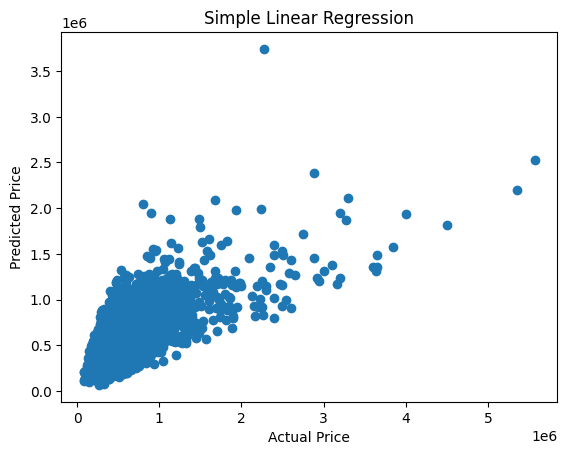

In [11]:
plt.scatter(y_test_s, y_pred_s)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Simple Linear Regression")
plt.show()

- Simple Linear Regression uses one feature and gives basic prediction
- Multiple Linear Regression improves accuracy using multiple features
- Polynomial Regression captures non-linear patterns and gives better performance
